# Create 3D Plot

## Libraries

In [ ]:
import numpy as np
import pandas as pd

import plotly.graph_objects as go

from pathlib import Path

## Functions and Definitions

The following function plots a time-wavelength-intensity UV/Vis spectrum. Either a _normal_ spectrum or a _water-adjusted_ spectrum can be plotted. _Water-adjusted_ means, that the initial wavelength-intensity spectrum (water) is subtracted from every other spectrum in the measurement. 

In [ ]:
def plot_3d_spectrum(folder_path, adjusted): 
    """
    Plots a 3D UV/Vis spectrum from measurement files stored in folder.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing the UV/Vis measurement files.
    adjusted : bool
        If False, the normal spectrum is plotted.
        If True, the spectrum is water-adjusted.
    """

    # Definitions
    folder = Path(folder_path) 
    intensity_df = pd.DataFrame()  # Intensities from every file in the folder will be stored in this dataframe to enable subsequent plotting. 
    i = 0  # Index variable to name new columns in 'intensity_df'
    wavelength = None  # In 'wavelength' all registered wavelengths will be listed.
    

    # Find out flow speed based on folder name.
    speed = ""
    for ch in folder.name:
        if ch.isdigit():
            speed = speed + ch


    # Fill 'intensity_df' 
    for file in sorted(folder.glob("*.txt")): 

        data = pd.read_csv(file, skiprows=5, sep=";") 

        if wavelength is None:  
            # 'wavelength' and 'water' are created solely in first iteration.
            wavelength = data.iloc[1:,0].str.replace(",", ".").astype(float) 
            water = data.iloc[1:,1].str.replace(",", ".").astype(float)  # Register water intensities

        intensity = data.iloc[1:,1].str.replace(",", ".").astype(float)  # Register intensities
        if adjusted: intensity = intensity - water  # If plot is to be adjusted, then subtract water intensity from every corresponding intensity.

        # Append 'intensity' to 'intensity_df' and label new column to avoid 'DublicateError'.
        intensity.name = f"No_{i}" 
        intensity_df = pd.concat([intensity_df, intensity], axis=1)

        i += 1


    if adjusted: intensity_df = intensity_df.mul(-1)  # Flip adjusted spectrum
    intensity_df = intensity_df / intensity_df.max().max()  # Normalization using global maximum
     
    time = np.arange(len(intensity_df.columns))  # Each column in 'intensity_df' corresponds to one second.


    # Plot
    # ----
    # Set grids
    time_grid, wavelength_grid = np.meshgrid(time, wavelength)

    fig = go.Figure()

    # Assign values to axes
    fig.add_trace(go.Surface(
        x=wavelength_grid,  # X-axis: wavelength
        y=time_grid,        # Y-axis: time
        z=intensity_df,      # Z-axis: intensity
        colorscale="Turbo",  # Color scale for intensity
    ))

    # Set layout
    fig.update_layout(
        font_family="Arial",
        title=dict(  # Set title
            text=f"{'adjusted ' if adjusted else ''}UV/Vis 3D Plot, v = {speed} mL/min",
            font=dict(
                family="Arial",
                size=20,
                color="black"
            )
        ),
        scene=dict(  # Set axis titles
            xaxis_title="Wavelength [nm]",
            yaxis_title="Time [s]",
            zaxis_title="Intensity [a.u.]"
        )
    )

    fig.show()

## Examples

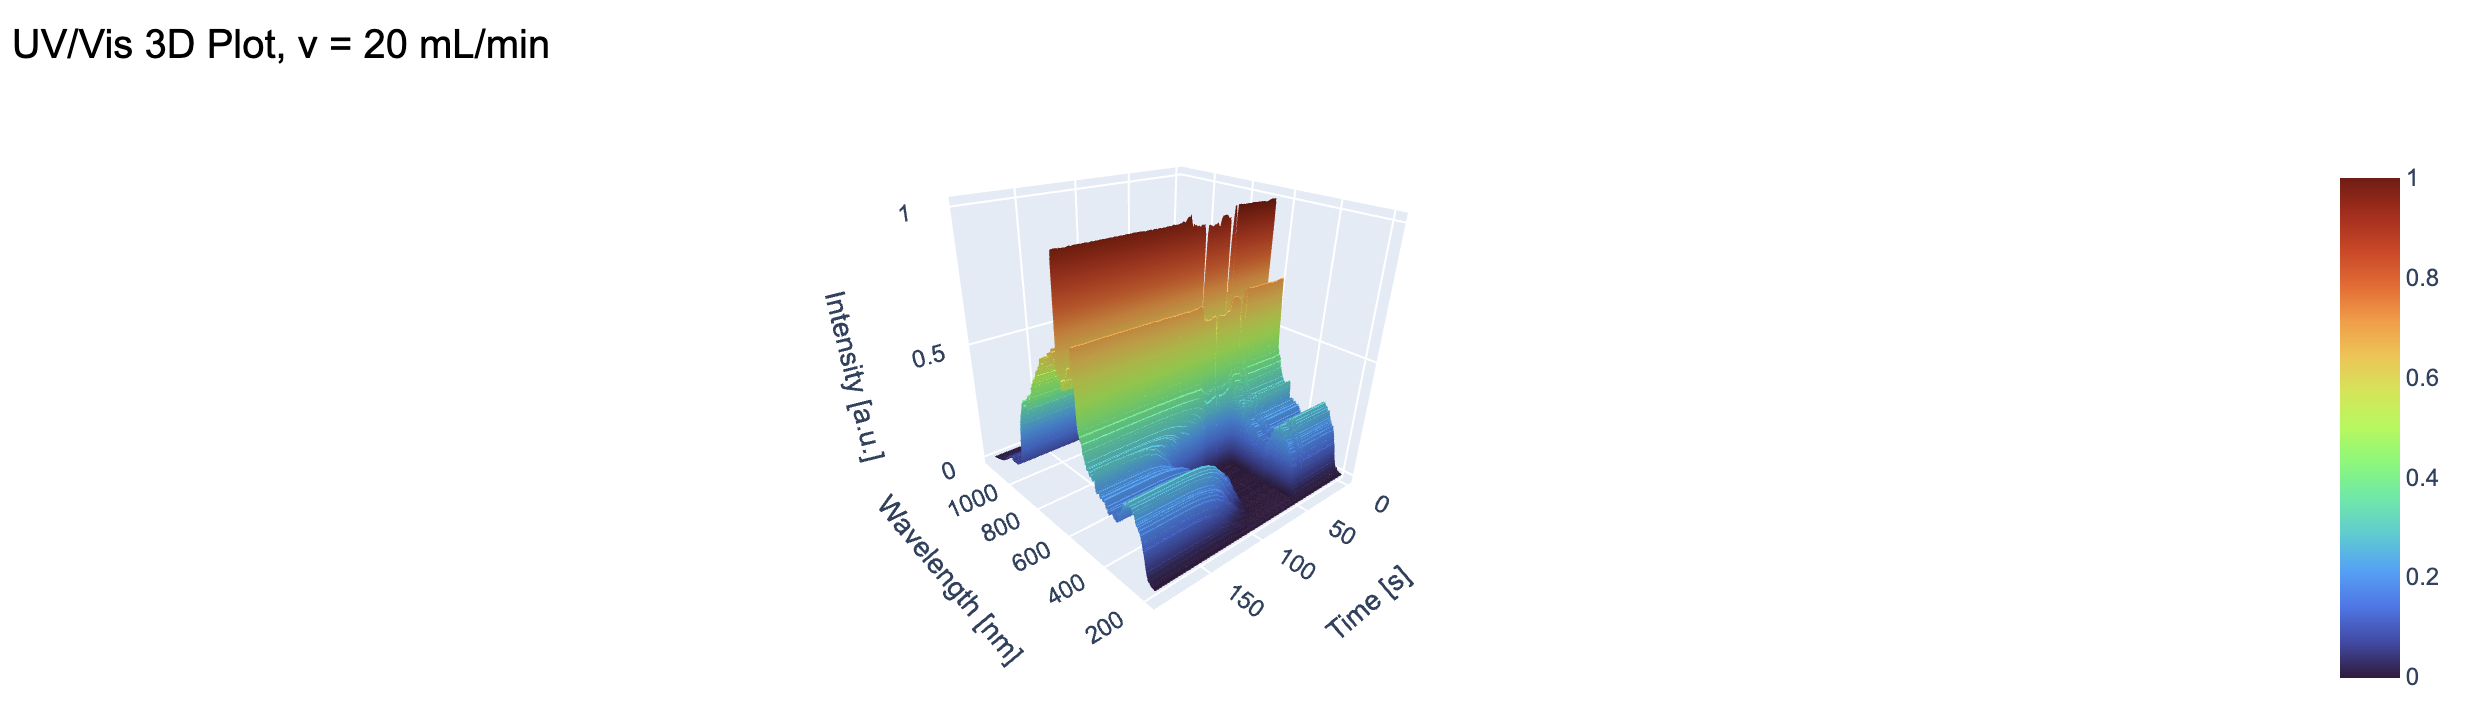

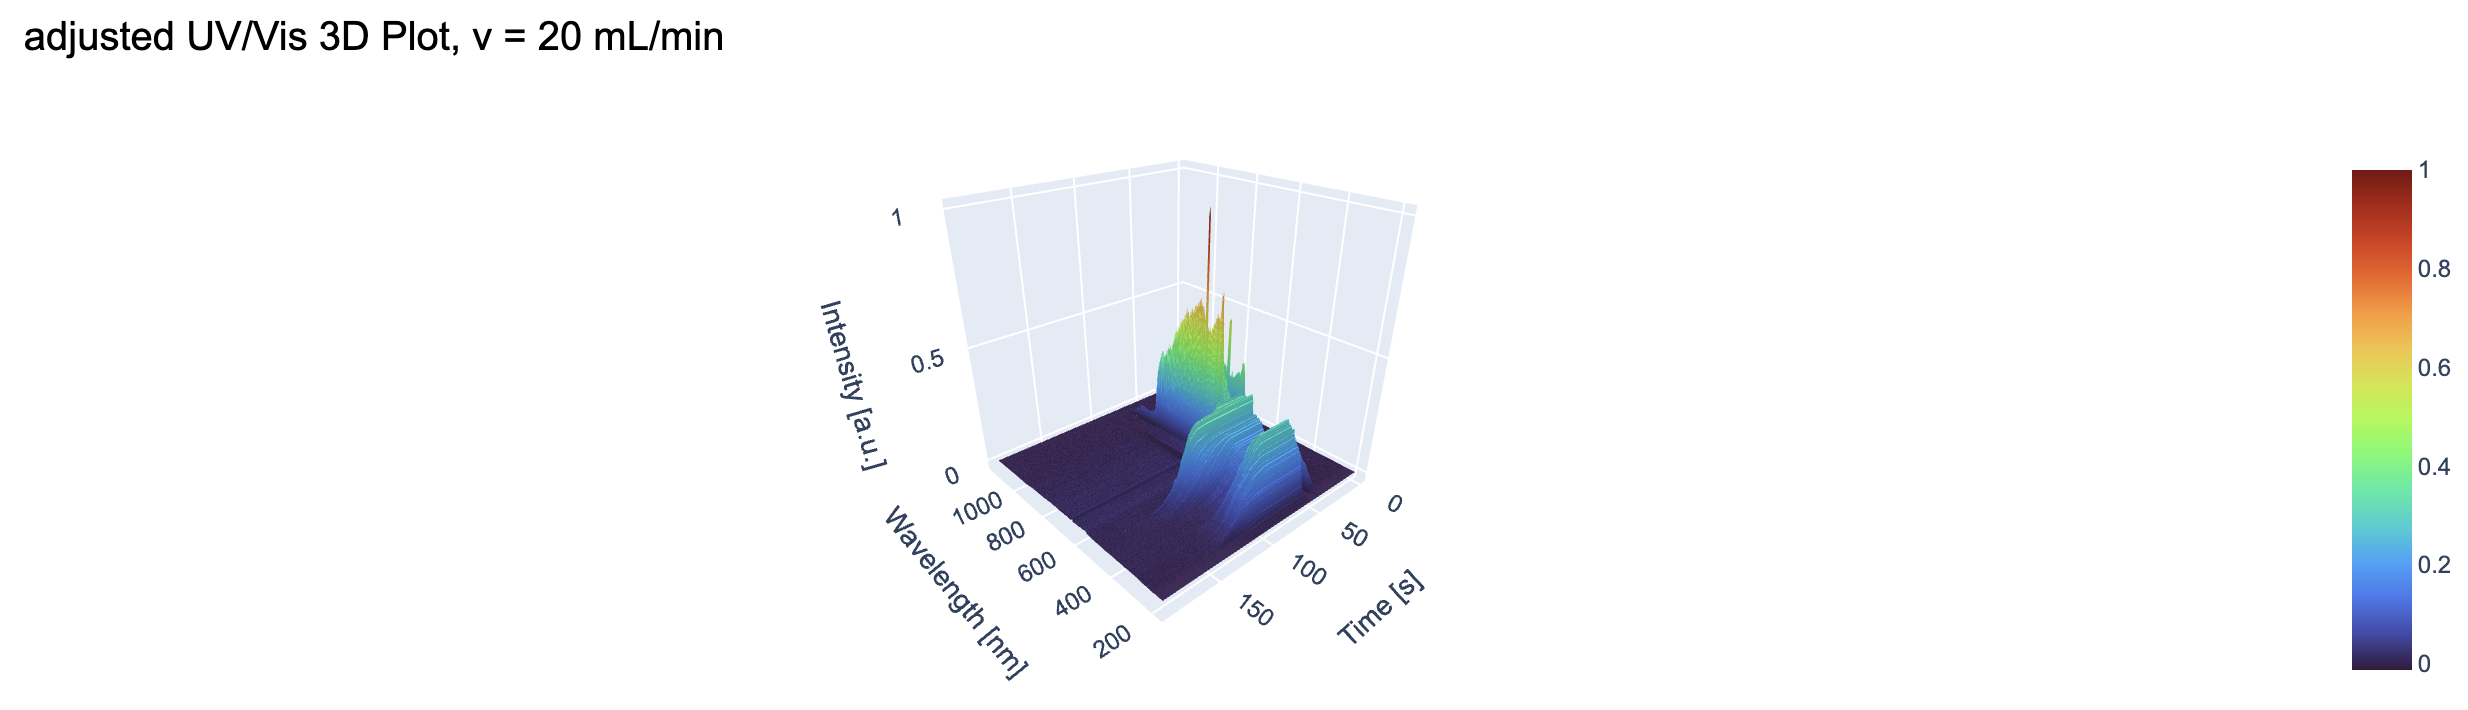

In [ ]:
# Plot the normal and water-adjusted 3D spectrum of the fluorescein test series with flow speed of 20 mL/min.
path = "../data/test_series_spectroscopy/spectroscopy_fluorescein_20"
plot_3d_spectrum(path, adjusted=False)
plot_3d_spectrum(path, adjusted=True)

Note: Occasionally the water spectrum appears in the adjusted data. Since the same water spectrum is subtracted from all spectra in the plot, air spectra (with intensities ~0) result in the inverted water spectrum after subtraction. After flipping the plot, it appears as if water was measured, although this is not the case.